# Musical Evolution Analysis: 1950s–2020s

This exploratory study uses eight curated playlists, up to 100 tracks each, with stored metadata and lyric-derived metrics. These are convenience samples, not representative samples of all music in a decade; the playlist IDs do not establish official Spotify ownership. Playlist decade labels can differ from album/reissue years.

TextBlob polarity and subjectivity are lexical model scores, not measurements of an artist’s feelings. Lexical richness is a length-sensitive type-token ratio; words per minute divides transcript word count by full track duration and is not measured vocal delivery speed. Raw lyrics are not redistributed. The default run replays the cached data; optional API refresh writes to a separate directory.


## Initial Setup

In [1]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import lyricsgenius as lg
import pandas as pd
import requests
import os
from pathlib import Path
import logging
import re
import time
from textblob import TextBlob
import nltk
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text 
import numpy as np
from tqdm import tqdm
from IPython.display import display
from scripts.recompute_metrics import lyric_metrics

###  1. Keys / Credentials


In [2]:
# Default: reproduce the committed derived data without API access.
REFRESH = os.getenv("MUSIC_REFRESH", "0") == "1"
DATA_DIR = Path(os.getenv("MUSIC_OUTPUT_DIR", "data/refresh")) if REFRESH else Path(".")
CLIENT_ID = os.getenv("SPOTIFY_CLIENT_ID")
CLIENT_SECRET = os.getenv("SPOTIFY_CLIENT_SECRET")
GENIUS_TOKEN = os.getenv("GENIUS_TOKEN")
if REFRESH:
    if not all([CLIENT_ID, CLIENT_SECRET, GENIUS_TOKEN]):
        raise RuntimeError("Refresh requires SPOTIFY_CLIENT_ID, SPOTIFY_CLIENT_SECRET and GENIUS_TOKEN")
    nltk.data.find('tokenizers/punkt_tab/english')
    DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Mode:", "API refresh into a separate output directory" if REFRESH else "cached derived-data reproduction")


Mode: cached derived-data reproduction


### 2. Network Configuration


In [3]:
session = requests.Session() # Honor the caller’s proxy/network configuration.


### 3. Connection

In [4]:
sp = genius = None
if REFRESH:
    auth = SpotifyClientCredentials(client_id=CLIENT_ID, client_secret=CLIENT_SECRET)
    sp = spotipy.Spotify(auth_manager=auth, requests_session=session)
    genius = lg.Genius(GENIUS_TOKEN, verbose=False, timeout=15)


### 4. Playlists

In [5]:
playlists_decades = {
    '1950s': '0hrPYkom4Vc1U3ep5lTpki',
    '1960s': '6X4MXiEwRohLqNUE67f9m4',
    '1970s': '5WJDB8X3AiksWiOMPVDFDf',
    '1980s': '2ikyATwHL2gdCMNlIblSmb',
    '1990s': '6w115bkFS6AsSWTkXTxUWL',
    '2000s': '6WMRgS5nbzjM6xvhZppKDl',
    '2010s': '04WQqIiZB8qXsirRwDFPbX',
    '2020s': '3L3yHSJle9RT8QHbpiSZpI'
}

### 5. Function definitions

In [6]:
def clean_lyrics(raw):
    return "\n".join(line for line in raw.splitlines() if not line.lstrip().startswith("[") and line.strip())


In [7]:
def generate_dataset(playlists, limit=None):
    master_list = []
    print(f"Starting extraction...")
    
    # Cache to avoid querying the same artist's genre twice
    genre_cache = {}

    for decade, playlist_id in playlists.items():
        print(f"\nProcessing Decade: {decade}...")
        
        try:
            if limit:
                results = sp.playlist_tracks(playlist_id, limit=limit)
                tracks = results['items']
            else:
                results = sp.playlist_tracks(playlist_id)
                tracks = results['items']
                while results['next']:
                    results = sp.next(results)
                    tracks.extend(results['items'])
        except Exception as e:
            print(f"Error downloading playlist {decade}: {e}")
            raise RuntimeError(f'Playlist retrieval failed for {decade}') from e

        print(f"Analyzing {len(tracks)} songs...")

        for i, item in enumerate(tracks):
            track = item['track']
            if not track or not track.get('artists') or track.get('type', 'track') != 'track': continue
            
            name = track['name']
            artist = track['artists'][0]['name']
            artist_id = track['artists'][0]['id']
            
            # Default values
            genres = []
            final_lyrics = None
            genius_visits = 0
            num_writers = 0
            polarity = np.nan
            subjectivity = np.nan
            total_words = 0
            lexical_richness = np.nan
            words_per_minute = np.nan
            
            # 1. SPOTIFY DATA
            if artist_id in genre_cache:
                genres = genre_cache[artist_id]
            else:
                try:
                    artist_info = sp.artist(artist_id)
                    genres = artist_info['genres']
                    genre_cache[artist_id] = genres
                except:
                    pass

            # 2. GENIUS DATA & NLP
            try:
                song = genius.search_song(title=name, artist=artist)
                
                if song:
                    try:
                        genius_visits = getattr(song.stats, 'pageviews', 0)
                    except:
                        genius_visits = 0
                    
                    try:
                        if hasattr(song, 'writer_artists'):
                            num_writers = len(song.writer_artists)
                    except:
                        num_writers = 0

                    if song.lyrics:
                        final_lyrics = clean_lyrics(song.lyrics)
                        
                        metrics = lyric_metrics(final_lyrics, round(track['duration_ms'] / 60000, 2))
                        polarity = metrics['Polarity']
                        subjectivity = metrics['Subjectivity']
                        total_words = metrics['Total Words']
                        lexical_richness = metrics['Lexical Richness (%)']
                        words_per_minute = metrics['Words per Minute']

            except Exception as e:
                logging.warning("Lyric metrics unavailable for %s / %s: %s", artist, name, type(e).__name__)

            # 3. APPEND TO LIST
            master_list.append({
                'Decade': decade,
                'Year': track['album']['release_date'][:4],
                'Song': name,
                'Artist': artist,
                'Genres': ", ".join(genres),
                'Popularity': track.get('popularity', np.nan),
                'Duration (min)': round(track['duration_ms'] / 60000, 2),
                'Explicit': track['explicit'],

                # Computed Metrics
                'Polarity': polarity,
                'Subjectivity': subjectivity,
                'Total Words': total_words,
                'Lexical Richness (%)': lexical_richness,
                'Words per Minute': words_per_minute,
                'Lyrics': final_lyrics
            })
            
            if (i+1) % 5 == 0:
                print(f"{i+1} processed...")

    return pd.DataFrame(master_list)

### 6. Execution

In [8]:
if REFRESH:
    df_final = generate_dataset(playlists_decades, limit=100)
    if df_final.empty:
        raise RuntimeError("No playlist tracks were retrieved")
    df_final.drop(columns=['Lyrics'], errors='ignore').to_csv(DATA_DIR / 'dataset_music.csv', index=False, encoding='utf-8-sig')
else:
    df_final = pd.read_csv(DATA_DIR / 'dataset_music.csv')
print(f"Loaded {len(df_final)} playlist rows")


Loaded 800 playlist rows


### 7. Load the local copy

In [9]:
# The persisted snapshots contain derived metrics, not raw lyrics.
assert not df_final.empty
assert {'Artist','Song','Decade','Total Words','Genres'}.issubset(df_final.columns)


## Part 1: ETL

We first check for any missing values in the dataframe: NaNs and 0s

In [10]:
# 1. Count NaNs (null values) per column
nan_counts = df_final.isna().sum()

# 2. Count Zeros per column
# For boolean columns (like 'Explicit'), 0 represents False.
# For numeric columns, it represents the actual number 0.
zero_counts = (df_final == 0).sum()

# Create a summary dataframe
summary = pd.DataFrame({'NaN Count': nan_counts, 'Zero Count': zero_counts})

# Filter to show only columns that have at least one NaN or Zero
relevant_cols = summary[(summary['NaN Count'] > 0) | (summary['Zero Count'] > 0)]

print("Summary of NaNs and Zeros per column:")
print(relevant_cols)

# 3. Breakdown by Decade
# We iterate through the relevant columns to see the distribution of these values across decades.
details = {}
for col in relevant_cols.index:
    # Analyze NaNs distribution by Decade
    if relevant_cols.loc[col, 'NaN Count'] > 0:
        nan_by_decade = df_final[df_final[col].isna()]['Decade'].value_counts()
        details[f"{col} - NaNs"] = nan_by_decade
    
    # Analyze Zeros distribution by Decade
    if relevant_cols.loc[col, 'Zero Count'] > 0:
        zero_by_decade = df_final[df_final[col] == 0]['Decade'].value_counts()
        details[f"{col} - Zeros"] = zero_by_decade

print("\nBreakdown by Decade:")
for key, value in details.items():
    print(f"\n{key}:")
    print(value)

Summary of NaNs and Zeros per column:
                      NaN Count  Zero Count
Genres                      313           0
Explicit                      0         706
Polarity                    116          20
Subjectivity                116          17
Total Words                   0         116
Lexical Richness (%)        116           0
Words per Minute            116           0

Breakdown by Decade:

Genres - NaNs:
Decade
2020s    64
2000s    57
2010s    57
1980s    45
1990s    39
1970s    30
1960s    20
1950s     1
Name: count, dtype: int64

Explicit - Zeros:
Decade
1950s    100
1960s    100
1970s    100
1980s     98
1990s     96
2010s     77
2000s     76
2020s     59
Name: count, dtype: int64

Polarity - NaNs:
Decade
1980s    26
1950s    21
1970s    21
1960s    19
1990s    16
2020s     6
2010s     5
2000s     2
Name: count, dtype: int64

Polarity - Zeros:
Decade
2020s    7
2000s    5
1990s    3
1950s    1
1960s    1
1970s    1
1980s    1
2010s    1
Name: count, dtype: int64


#### Interpreting Missing and Zero Values

The tables above report counts from the current snapshot. A missing genre may reflect unavailable metadata, and a zero word count may reflect either an instrumental or failed retrieval. Zero polarity can also be a valid model score. `Explicit=False` is a metadata flag, not evidence of censorship or cultural causes. The snapshots omit raw lyrics, so text availability is inferred only from the stored word count.


The next table identifies missing genre tags and unavailable derived lyric metrics.


In [11]:
cond_genre = df_final['Genres'].isna()
cond_lyrics = df_final['Total Words'].isna() | (df_final['Total Words'] <= 0)

df_final['Problem_Type'] = None
df_final['Problem_Type'] = df_final['Problem_Type'].astype('object')

df_final.loc[cond_genre & cond_lyrics, 'Problem_Type'] = 'Both Missing'
df_final.loc[cond_genre & ~cond_lyrics, 'Problem_Type'] = 'Missing Genre Only'
df_final.loc[~cond_genre & cond_lyrics, 'Problem_Type'] = 'Missing Lyrics Only'

summary = df_final[df_final['Problem_Type'].notna()].groupby(['Decade', 'Problem_Type']).size().unstack(fill_value=0)
summary['Total Issues'] = summary.sum(axis=1)
total_row = summary.sum().to_frame().T
total_row.index = ['Total']
final_summary = pd.concat([summary, total_row])

print("--- Summary of Issues by Decade ---")
table_str = final_summary.astype(int).to_markdown()
lines = table_str.split('\n')
lines.insert(-1, lines[1]) 
print('\n'.join(lines))

print("\n--- Detailed List (Sample) ---")
cols = ['Decade', 'Problem_Type', 'Song', 'Artist']
print(df_final[df_final['Problem_Type'].notna()][cols].head().to_markdown(index=False))

df_problems = df_final[df_final['Problem_Type'].notna()].copy()

--- Summary of Issues by Decade ---
|       |   Both Missing |   Missing Genre Only |   Missing Lyrics Only |   Total Issues |
|:------|---------------:|---------------------:|----------------------:|---------------:|
| 1950s |              1 |                    0 |                    20 |             21 |
| 1960s |              2 |                   18 |                    17 |             37 |
| 1970s |              5 |                   25 |                    16 |             46 |
| 1980s |             10 |                   35 |                    16 |             61 |
| 1990s |              5 |                   34 |                    11 |             50 |
| 2000s |              1 |                   56 |                     1 |             58 |
| 2010s |              3 |                   54 |                     2 |             59 |
| 2020s |              4 |                   60 |                     2 |             66 |
|:------|---------------:|---------------------:|-----

Title normalization is used only by the optional enrichment step. It can improve retrieval but does not prove that a returned lyric matches the intended recording.


In [12]:
df_cleaned = df_problems.copy()

def clean_song_title(title):
    if not isinstance(title, str): return str(title)
    
    # Remove everything after " - " (remasters, versions)
    if " - " in title: title = title.split(" - ")[0]
    
    # Remove content inside parentheses and brackets
    title = re.sub(r"\(.*?\)|\[.*?\]", "", title)
    
    # Remove "feat." or "ft." 
    title = re.sub(r"(?i)\b(feat\.?|ft\.?)\b.*", "", title)
    
    # Remove quotes
    title = title.replace('"', '').replace("'", "")
    
    # Normalize common abbreviations (The "Mister" -> "Mr." fix)
    replacements = {r"\bMister\b": "Mr.", r"\bDoctor\b": "Dr.", r"\bSaint\b": "St."}
    for pat, rep in replacements.items():
        title = re.sub(pat, rep, title, flags=re.IGNORECASE)

    return " ".join(title.split())

df_cleaned['Cleaned_Song'] = df_cleaned['Song'].apply(clean_song_title)


In cached mode, load the stored repair table. Optional refresh retries lyric retrieval and computes derived metrics; failed requests remain missing and are reported.


In [13]:
if REFRESH:
    
    # --- CONFIGURATION ---
    GENIUS_TOKEN = os.getenv("GENIUS_TOKEN")
    if not GENIUS_TOKEN:
        raise RuntimeError("Set GENIUS_TOKEN in the environment before requesting lyrics.")
    genius = lg.Genius(GENIUS_TOKEN, verbose=False, remove_section_headers=True, timeout=15)
    
    # --- PROCESSING ---
    print(f"Starting enrichment for {len(df_problems)} songs...")
    
    df_work = df_cleaned.copy()
    
    tqdm.pandas(desc="Fetching Lyrics")
    
    def fetch_and_calculate(row):
        # Skip if the problem is only a missing genre (we focus on lyrics here)
        if row['Problem_Type'] == 'Missing Genre Only':
            return row 
    
        lyrics = None
        target = row['Cleaned_Song']
        artist = row['Artist']
        
        # 1. SEARCH LYRICS
        try:
            # Strategy A: Cleaned Title
            song = genius.search_song(target, artist)
            
            # Strategy B: Broad Search (Smart Match) if A fails
            if not song:
                hits = genius.search_songs(target)
                if hits and 'hits' in hits:
                    for hit in hits['hits'][:3]:
                        h_artist = hit['result']['primary_artist']['name']
                        # Check if artist matches (one is inside the other)
                        if artist.lower() in h_artist.lower() or h_artist.lower() in artist.lower():
                            song = genius.search_song(hit['result']['title'], h_artist)
                            break
            
            if song and song.lyrics:
                lyrics = song.lyrics
        except Exception as exc:
            logging.warning("Lyrics lookup failed for %s — %s: %s", artist, target, exc)
    
        # 2. CALCULATE METRICS (If lyrics found)
        if lyrics:
            row['Lyrics'] = lyrics
            
            for key, value in lyric_metrics(lyrics, row['Duration (min)']).items():
                row[key] = value

        return row
    
    # Apply the function
    df_repaired = df_work.progress_apply(fetch_and_calculate, axis=1)
    
    # Filter: Keep only the successfully repaired songs
    df_fixed_final = df_repaired[df_repaired['Lyrics'].notna() & (df_repaired['Total Words'] > 0)].copy()
    
    # Cleanup: Remove the temporary helper column
    if 'Cleaned_Song' in df_fixed_final.columns:
        df_fixed_final = df_fixed_final.drop(columns=['Cleaned_Song'])
    
    # Persist derived metrics only; lyrics are not redistributed.
    df_fixed_final = df_fixed_final.drop(columns=['Lyrics'], errors='ignore')
    df_fixed_final.to_csv(DATA_DIR / 'dataset_fixed.csv', index=False)
    print(f"Success! Saved {len(df_fixed_final)} repaired songs to 'dataset_fixed.csv'")
else:
    df_fixed_final = pd.read_csv(DATA_DIR / 'dataset_fixed.csv')
    print(f'Loaded {len(df_fixed_final)} cached repair rows')


Loaded 393 cached repair rows


The repair-row count is shown above. It includes rows retained from the problem table, so it is not a count of newly recovered lyrics. Merge by artist and song after checking duplicates.


In [14]:
# Check for duplicates based on Artist and Song
duplicates = df_final[df_final.duplicated(subset=['Artist', 'Song'], keep=False)]

print(f"Found {len(duplicates)} duplicate rows.")
print(duplicates[['Artist', 'Song', 'Decade']].sort_values(by='Song').head(10))

Found 10 duplicate rows.
              Artist                            Song Decade
544        Lady Gaga                     Bad Romance  2000s
662        Lady Gaga                     Bad Romance  2010s
206         The Cure                  Boys Don't Cry  1970s
317         The Cure                  Boys Don't Cry  1980s
318     Depeche Mode               Enjoy the Silence  1980s
417     Depeche Mode               Enjoy the Silence  1990s
214  Michael Jackson  Rock with You - Single Version  1970s
332  Michael Jackson  Rock with You - Single Version  1980s
248      The Buggles     Video Killed The Radio Star  1970s
362      The Buggles     Video Killed The Radio Star  1980s


Duplicate artist/song pairs are collapsed to their first occurrence. This also assigns songs appearing in multiple playlists to their first recorded decade; playlist selection remains a source of bias.


In [15]:
df_merged = df_final.copy()

# Clean the destination
df_merged = df_merged.drop_duplicates(subset=['Artist', 'Song'], keep='first')

# Clean the source
df_fixed_final = df_fixed_final.drop_duplicates(subset=['Artist', 'Song'], keep='first')

print(f"Unique rows in Main DB: {len(df_merged)}")
print(f"Unique rows in Updates: {len(df_fixed_final)}")

# Set indices for the merge
df_merged = df_merged.set_index(['Artist', 'Song'])
df_updates = df_fixed_final.set_index(['Artist', 'Song'])

df_merged.update(df_updates)

# Reset index to return to normal
df_merged = df_merged.reset_index()

# Cleanup error labels
fixed_indices = df_updates.index
mask_fixed = df_merged.set_index(['Artist', 'Song']).index.isin(fixed_indices)
df_merged.loc[mask_fixed, 'Problem_Type'] = None

# Verification
def count_issues(df):
    # Count rows where Lyrics are missing (NaN) OR Total Words is 0
    return int((df['Total Words'].isna() | (df['Total Words'] <= 0)).sum())

print("\n--- Final Result ---")
print(f"Issues before merge: {count_issues(df_final)}")
print(f"Issues after merge:  {count_issues(df_merged)}")

Unique rows in Main DB: 795
Unique rows in Updates: 391

--- Final Result ---
Issues before merge: 116
Issues after merge:  5


Check derived-metric availability after merging the cached repairs.


In [16]:
print("Derived-data health after merging:")
print(f"Missing genres: {df_merged['Genres'].isna().sum()}")
print(f"Missing/zero word counts: {count_issues(df_merged)}")
print("Raw lyrics are absent from distributed snapshots; text matching is not verified by these checks.")


Derived-data health after merging:
Missing genres: 311
Missing/zero word counts: 5
Raw lyrics are absent from distributed snapshots; text matching is not verified by these checks.


The optional refresh attempts to obtain missing genre labels. Genius tags and Spotify artist genres are different taxonomies; their mixture is used only as an exploratory grouping.


In [17]:
if REFRESH:
    # 1. Identify rows that need Genre repair
    # We filter where Genres is NaN
    missing_genre_mask = df_merged['Genres'].isna()
    df_missing_genres = df_merged[missing_genre_mask].copy()
    
    print(f"Attempting to find genres for {len(df_missing_genres)} songs using Genius Tags...")
    
    # 2. Function to fetch Tags
    def fetch_genius_tags(row):
        try:
            # Search for the song
            song = genius.search_song(row['Song'], row['Artist'])
            
            if song:
                # genius_song.to_dict() returns a dictionary with metadata including tags
                # We assume the library returns a 'tags' key in the dictionary representation
                data = song.to_dict()
                
                # Extract tags (usually a list of dicts like [{'name': 'Pop'}, ...])
                # Depending on the library version, it might be directly in 'tags'
                tags = []
                if 'tags' in data:
                    tags = [t['name'] for t in data['tags']]
                
                # If no tags in the top level, sometimes they are in primary_tag
                if not tags and 'primary_tag' in data and data['primary_tag']:
                    tags.append(data['primary_tag']['name'])
    
                # Join them into a string (e.g., "Pop, Rock, Soul")
                if tags:
                    return ", ".join(tags[:3]) # Take top 3 tags
                    
        except Exception as e:
            return None
        
        return None
    
    # 3. Apply the function
    tqdm.pandas(desc="Fetching Genres")
    df_missing_genres['Found_Tags'] = df_missing_genres.progress_apply(fetch_genius_tags, axis=1)
    
    # 4. Update the Main DataFrame
    # We only want to update where we actually found something
    filled_genres = df_missing_genres[df_missing_genres['Found_Tags'].notna()]
    
    # Update the 'Genres' column in the main df using the indices
    df_merged.loc[filled_genres.index, 'Genres'] = filled_genres['Found_Tags']
    
    # 5. Final Check
    remaining = df_merged['Genres'].isna().sum()
    print(f"-------------------------------")
    print(f"Genres recovered: {len(filled_genres)}")
    print(f"Still missing:    {remaining}")
else:
    print('Genre enrichment skipped in cached mode')


Genre enrichment skipped in cached mode


Missing genres are labeled Unknown. Rows with fewer than four stored words are excluded from lyric analysis; unavailable retrieval is not equivalent to an instrumental recording.


In [18]:
df_merged['Genres'] = df_merged['Genres'].fillna('Unknown')
rows_before = len(df_merged)
df_merged = df_merged.loc[df_merged['Total Words'].ge(4)].drop(columns=['Lyrics'], errors='ignore').copy()
print(f"Excluded {rows_before-len(df_merged)} rows with fewer than four recorded words")
print(f"Final derived rows: {len(df_merged)}")
if REFRESH:
    df_merged.to_csv(DATA_DIR / 'dataset_final_completed.csv', index=False, encoding='utf-8-sig')


Excluded 6 rows with fewer than four recorded words
Final derived rows: 789


In [19]:
df = pd.read_csv(DATA_DIR / 'dataset_final_completed.csv')
# Check that the cached extraction + repair stages reproduce the final numeric metrics.
key = ['Artist','Song']
metrics = ['Popularity','Duration (min)','Explicit','Polarity','Subjectivity','Total Words','Lexical Richness (%)','Words per Minute']
replayed = df_merged.set_index(key).sort_index()
stored = df.set_index(key).sort_index()
assert replayed.index.equals(stored.index)
pd.testing.assert_frame_equal(replayed[metrics], stored[metrics], check_dtype=False, atol=1e-8)
assert not df.duplicated(key).any()
assert np.isfinite(df[metrics].to_numpy(dtype=float)).all()
assert df['Duration (min)'].gt(0).all() and df['Total Words'].ge(4).all()
assert df['Polarity'].between(-1,1).all() and df['Subjectivity'].between(0,1).all()
assert df['Lexical Richness (%)'].between(0,100).all()
assert df['Explicit'].isin([True,False]).all()
print('Cached ETL parity and metric range checks passed')


Cached ETL parity and metric range checks passed


## Part 2: Lexical Richness

The type-token ratio divides distinct lowercased tokens by total tokens. It depends strongly on text length, transcription and tokenization, so it does not measure literary quality or semantic complexity. The following plot summarizes this sample without a population-level significance claim.


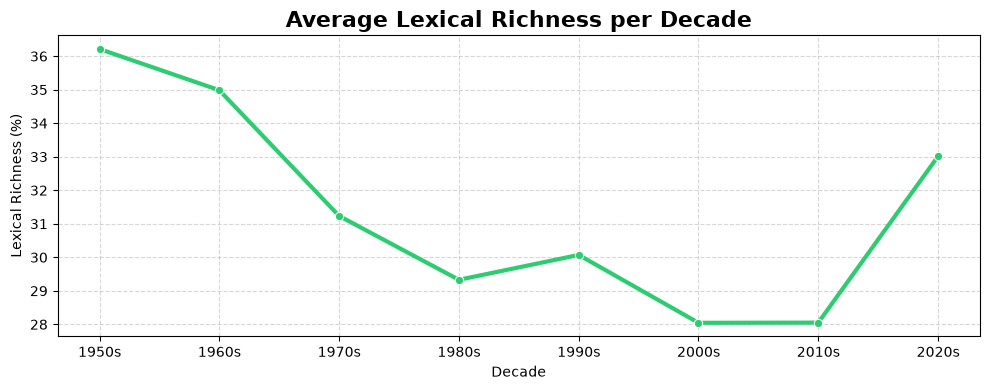

In [20]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='Decade', y='Lexical Richness (%)', marker='o', color='#2ecc71', linewidth=3, errorbar=None)
plt.title('Average Lexical Richness per Decade', fontsize=16, weight='bold')
plt.ylabel('Lexical Richness (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Track duration is shown separately. It is not the denominator of type-token ratio and cannot, by itself, explain changes in that ratio.


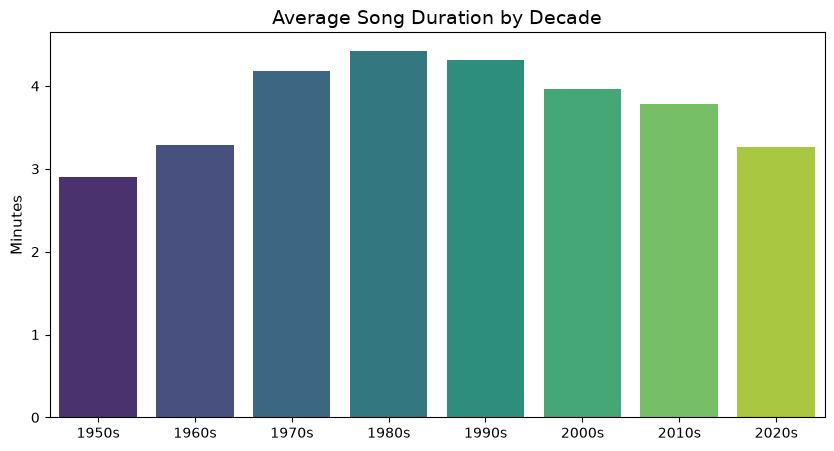

In [21]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Decade', y='Duration (min)', hue='Decade', errorbar=None, palette='viridis', legend=False)
plt.title('Average Song Duration by Decade', fontsize=14)
plt.ylabel('Minutes', fontsize=11)
plt.xlabel('')
plt.show()

The bars report average durations in the sampled playlists. Streaming incentives, listener attention and historical format changes were not measured; the chart cannot establish their causal effects.


The next plot identifies the largest and smallest type-token ratios within each sampled decade, after restricting to more than 20 stored words.


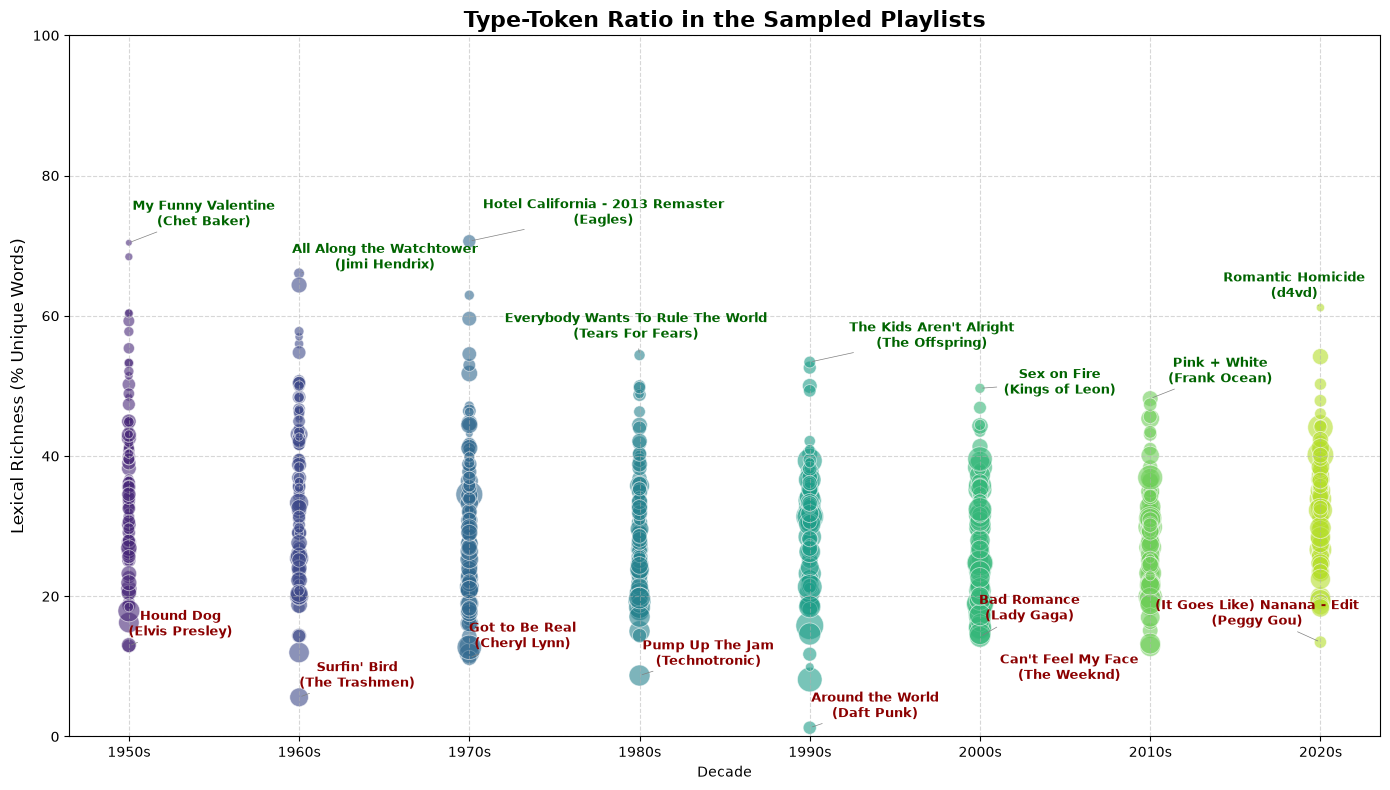

In [22]:
sns.set_theme(style="whitegrid")
plt.style.use('default')

def analyze_lexical_depth(df):

    # Filter valid lyrics: Ignore instrumental/intro tracks (less than 20 words) to avoid noise
    valid_data = df[(df['Total Words'] > 20)].copy()
    
    # Sort decades for correct plotting order
    valid_data = valid_data.sort_values('Decade')

    plt.figure(figsize=(14, 8))
    
    scatter = sns.scatterplot(
        data=valid_data, 
        x='Decade', 
        y='Lexical Richness (%)',
        size='Total Words',
        hue='Decade',
        sizes=(20, 400),
        alpha=0.6,
        palette='viridis',
        legend=False
    )

    texts = []
    
    for decade in valid_data['Decade'].unique():
        decade_data = valid_data[valid_data['Decade'] == decade]
        
        # Find extremes
        most_complex = decade_data.nlargest(1, 'Lexical Richness (%)')
        most_repetitive = decade_data.nsmallest(1, 'Lexical Richness (%)')
        
        # Label Highest (Green)
        for _, row in most_complex.iterrows():
            texts.append(plt.text(
                x=row['Decade'], 
                y=row['Lexical Richness (%)'], 
                s=f"{row['Song']}\n({row['Artist']})", 
                fontsize=9, 
                ha='center', 
                fontweight='bold',
                color='darkgreen'
            ))
            
        # Label Lowest (Red)
        for _, row in most_repetitive.iterrows():
            texts.append(plt.text(
                x=row['Decade'], 
                y=row['Lexical Richness (%)'], 
                s=f"{row['Song']}\n({row['Artist']})", 
                fontsize=9, 
                ha='center', 
                fontweight='bold',
                color='darkred'
            ))

    plt.title('Type-Token Ratio in the Sampled Playlists', fontsize=16, weight='bold')
    plt.ylabel('Lexical Richness (% Unique Words)', fontsize=12)
    plt.xlabel('Decade')
    plt.ylim(0, 100)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    np.random.seed(42)
    adjust_text(texts, expand=(1.1, 1.2), iter_lim=100, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, shrinkA=5))
    
    plt.tight_layout()
    plt.show()

analyze_lexical_depth(df)

Or even better, let's go the hall of fame of richness and repetition.

In [23]:
pd.set_option('display.max_colwidth', 30)
pd.set_option('display.width', 1000)

print("\n" + "="*60)
print("HALL OF RICHNESS")
print("="*60)
top_overall = df.nlargest(8, 'Lexical Richness (%)')
print(top_overall[['Decade', 'Song', 'Artist', 'Lexical Richness (%)', 'Total Words']].to_string(index=False))

print("\n" + "="*60)
print("HALL OF REPETITION")
print("="*60)
bottom_overall = df.nsmallest(8, 'Lexical Richness (%)')
print(bottom_overall[['Decade', 'Song', 'Artist', 'Lexical Richness (%)', 'Total Words']].to_string(index=False))



HALL OF RICHNESS
Decade                             Song           Artist  Lexical Richness (%)  Total Words
 1970s Hotel California - 2013 Remaster           Eagles                 70.64          235
 1950s               My Funny Valentine       Chet Baker                 70.42           71
 1950s     What A Diff'rence A Day Made Dinah Washington                 68.42           95
 1960s         All Along the Watchtower     Jimi Hendrix                 66.05          162
 1960s                        Bang Bang    Nancy Sinatra                 64.39          337
 1970s               Wish You Were Here       Pink Floyd                 62.94          143
 2020s                Romantic Homicide             d4vd                 61.17          103
 1950s                    Strange Fruit   Billie Holiday                 60.44           91

HALL OF REPETITION
Decade              Song       Artist  Lexical Richness (%)  Total Words
 1990s  Around the World    Daft Punk                  1.25  

## Part 3: Sentiment Scores

The charts summarize TextBlob scores from retrieved text. Lexicon coverage, language, negation, irony and transcript matching can affect these values. Differences between playlist means do not show that music, artists or listeners have become sadder, and no significance test or causal design is presented.


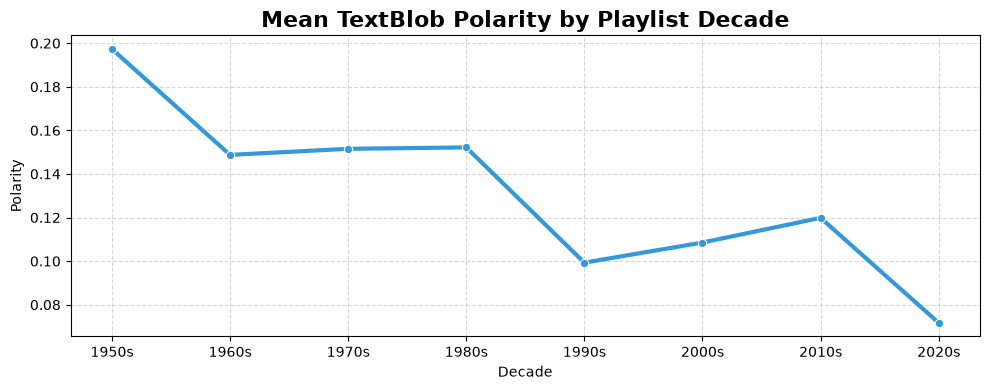

In [24]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='Decade', y='Polarity', marker='o', color='#3498db', linewidth=3, errorbar=None)
plt.title('Mean TextBlob Polarity by Playlist Decade', fontsize=16, weight='bold')
plt.ylabel('Polarity')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Subjectivity is another TextBlob score. It does not measure emotional detachment, numbness or factual truth; read the plotted averages as model outputs for these texts.


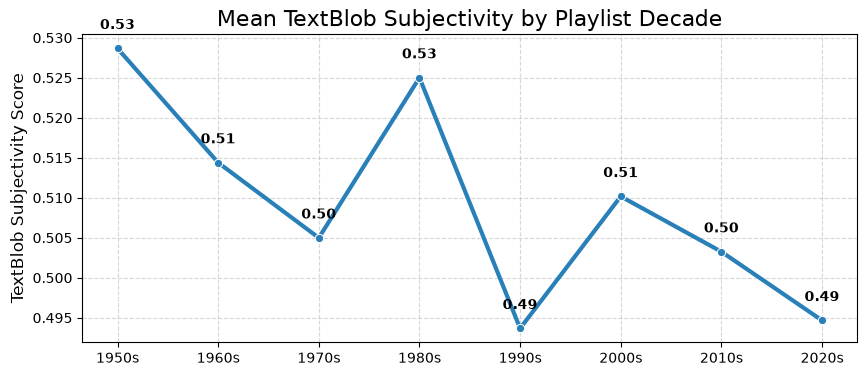

In [25]:
plt.figure(figsize=(10, 4))
subj_trend = df.groupby('Decade')['Subjectivity'].mean().reset_index()
sns.lineplot(data=subj_trend, x='Decade', y='Subjectivity', 
             marker='o', linewidth=3, color='#2980b9') # Blue for "Cold/Detached"

for x, y in zip(subj_trend['Decade'], subj_trend['Subjectivity']):
    plt.text(x, y + 0.002, f'{y:.2f}', ha='center', va='bottom', fontweight='bold')

plt.title('Mean TextBlob Subjectivity by Playlist Decade', fontsize=16)
plt.ylabel('TextBlob Subjectivity Score', fontsize=12)
plt.xlabel('')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

The explicit-content chart reports the fraction of metadata flags in each sampled playlist. It does not explain polarity or subjectivity changes.


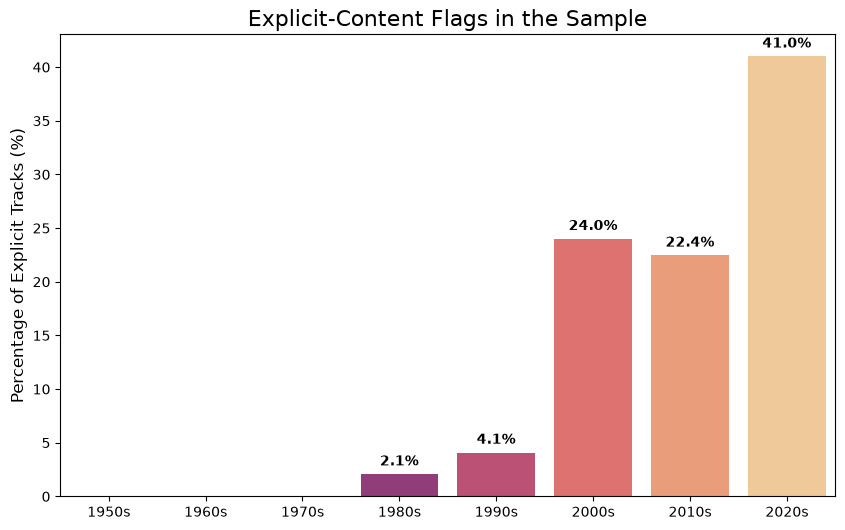

In [26]:
plt.figure(figsize=(10, 6))
explicit_trend = df.groupby('Decade')['Explicit'].mean().reset_index()
explicit_trend['Explicit_Pct'] = explicit_trend['Explicit'] * 100
barplot = sns.barplot(data=explicit_trend, x='Decade', y='Explicit_Pct', hue='Decade', palette='magma', legend=False)

for p in barplot.patches:
    if p.get_height() > 0: 
        barplot.annotate(f'{p.get_height():.1f}%', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha = 'center', va = 'center', 
                         xytext = (0, 9), 
                         textcoords = 'offset points',
                         fontweight='bold')

plt.title('Explicit-Content Flags in the Sample', fontsize=16)
plt.ylabel('Percentage of Explicit Tracks (%)', fontsize=12)
plt.xlabel('')
plt.show()

## Part 4: Recorded Word Density

This ratio is transcript words divided by full track duration, including instrumental sections. It is not vocal speed, syllables per minute, energy or evidence of an attention-economy effect. The plot reports the sample means.


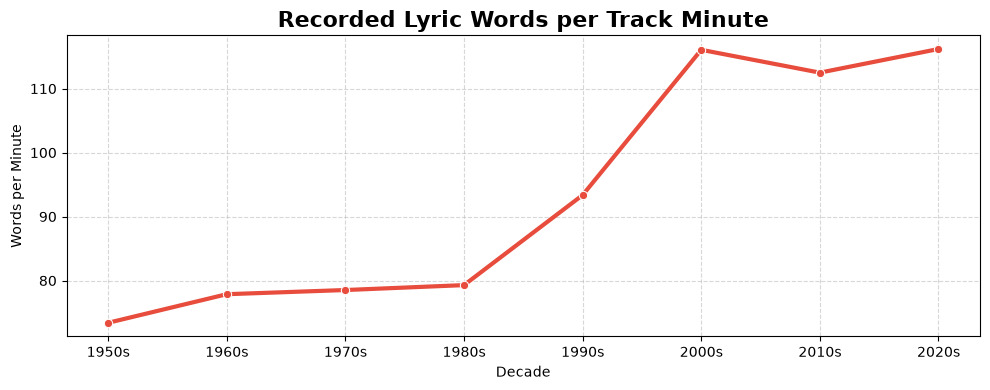

In [27]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='Decade', y='Words per Minute', marker='o', color='#e74c3c', linewidth=3, errorbar=None)
plt.title('Recorded Lyric Words per Track Minute', fontsize=16, weight='bold')
plt.ylabel('Words per Minute')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Genre strings are assigned to broad groups by the ordered keyword rules below. The excluded count includes both missing genres and unrecognized tags. The groups can overlap conceptually and depend on rule order; their boxplots do not establish genre influence or explain historical changes.


Total Songs: 789
Songs with Genre (Analyzed): 369
Songs outside the defined genre groups (excluded): 420


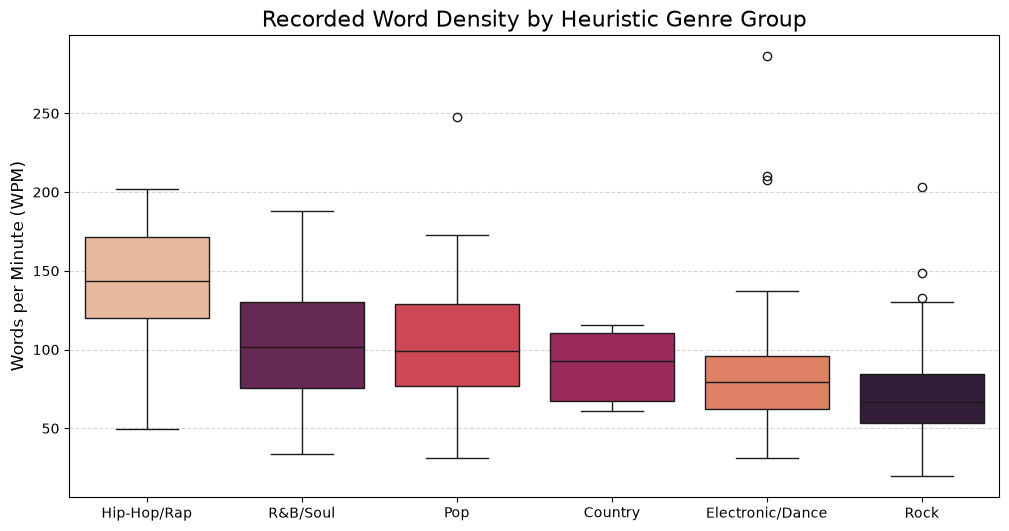

In [28]:
def classify_genre(genre_str):
    genre_str = str(genre_str).lower()
    
    if 'hip hop' in genre_str or 'rap' in genre_str or 'trap' in genre_str:
        return 'Hip-Hop/Rap'
    elif 'rock' in genre_str or 'metal' in genre_str or 'punk' in genre_str:
        return 'Rock'
    elif 'country' in genre_str or 'folk' in genre_str:
        return 'Country'
    elif 'r&b' in genre_str or 'soul' in genre_str or 'motown' in genre_str:
        return 'R&B/Soul'
    elif 'dance' in genre_str or 'electronic' in genre_str or 'house' in genre_str or 'disco' in genre_str:
        return 'Electronic/Dance'
    elif 'pop' in genre_str: 
        return 'Pop'
    else:
        return 'Other/Unknown'

df['Broad_Genre'] = df['Genres'].apply(classify_genre)
plot_genres = df[~df['Broad_Genre'].isin(['Other/Unknown'])]
total_songs = len(df)
analyzed_songs = len(plot_genres)
print(f"Total Songs: {total_songs}")
print(f"Songs with Genre (Analyzed): {analyzed_songs}")
print(f"Songs outside the defined genre groups (excluded): {total_songs - analyzed_songs}")
plt.figure(figsize=(12, 6))
order = plot_genres.groupby('Broad_Genre')['Words per Minute'].median().sort_values(ascending=False).index

sns.boxplot(
    data=plot_genres, 
    x='Broad_Genre', 
    y='Words per Minute', 
    hue='Broad_Genre',
    order=order, 
    palette='rocket',
    legend=False
)

plt.title('Recorded Word Density by Heuristic Genre Group', fontsize=16)
plt.ylabel('Words per Minute (WPM)', fontsize=12)
plt.xlabel('')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.show()

## Part 5: Correlations

These are descriptive Pearson correlations for the sampled playlists. Popularity reflects a snapshot of consumption, not a test of recommendation algorithms. Correlations with decade do not establish industry intentions, cultural mechanisms or causal effects. Zero correlation also does not rule out nonlinear relationships.


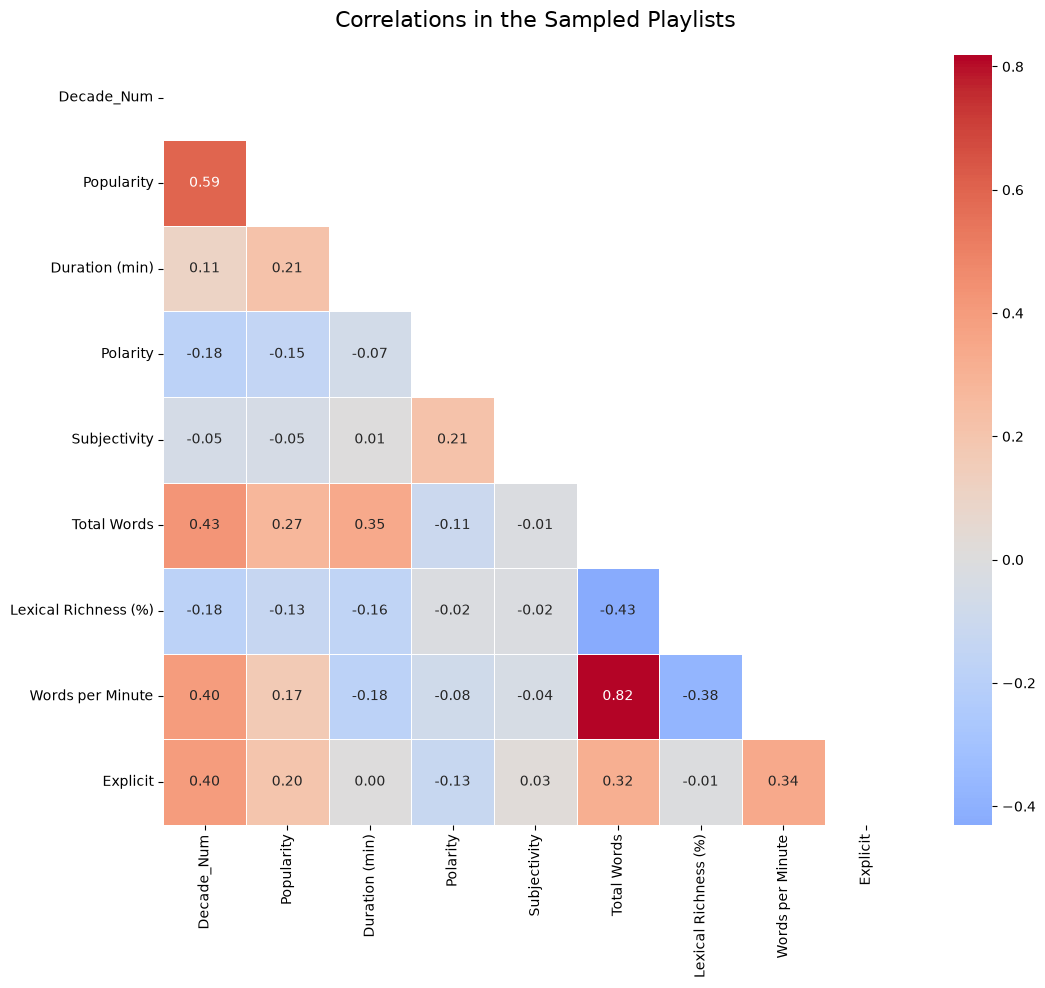

In [29]:
df['Decade_Num'] = df['Decade'].astype(str).str.extract(r'(\d+)').astype(float)

corr_cols = [
    'Decade_Num', 'Popularity', 'Duration (min)', 
    'Polarity', 'Subjectivity', 'Total Words', 
    'Lexical Richness (%)', 'Words per Minute', 'Explicit'
]

df_corr = df[corr_cols].copy()
df_corr['Explicit'] = df['Explicit'].astype(int)

corr_matrix = df_corr.corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    center=0, 
    linewidths=0.5
)

plt.title('Correlations in the Sampled Playlists', fontsize=16, pad=20)
plt.show()

The table lists extremes of the stored numerical scores. Its labels refer to those scores, not independently validated artistic or emotional qualities.


In [30]:
categories = [
    ("Highest Recorded Word Density", "Words per Minute", "max", " wpm"),
    ("Lowest Recorded Word Density", "Words per Minute", "min", " wpm"),
    ("⏳ Longest Epic", "Duration (min)", "max", " min"),
    ("⚡ Shortest Hit", "Duration (min)", "min", " min"),
    ("Highest Type-Token Ratio", "Lexical Richness (%)", "max", "%"),
    ("Lowest Type-Token Ratio", "Lexical Richness (%)", "min", "%"),
    ("Highest Polarity Score", "Polarity", "max", ""),
    ("Lowest Polarity Score", "Polarity", "min", ""),
    ("📝 Most Subjective", "Subjectivity", "max", ""),
    ("Lowest Subjectivity Score", "Subjectivity", "min", "")
]

hall_of_fame_data = []

for title, col, method, unit in categories:
    if method == 'max':
        idx = df[col].idxmax()
    else:
        idx = df[col].idxmin()
        
    row = df.loc[idx]
    
    hall_of_fame_data.append({
        "Award": title,
        "Song": row['Song'],
        "Artist": row['Artist'],
        "Score": f"{row[col]:.2f}{unit}",
        "Decade": row['Decade']
    })

hall_of_fame = pd.DataFrame(hall_of_fame_data)

styled_table = hall_of_fame.style.set_properties(**{'text-align': 'left', 'font-size': '11pt'})\
    .set_table_styles([dict(selector='th', props=[('text-align', 'left'), ('font-size', '12pt')])])\
    .hide(axis='index')

display(styled_table)

most_explicit_decade = df.groupby('Decade')['Explicit'].mean().idxmax()
percentage = df.groupby('Decade')['Explicit'].mean().max() * 100
print(f"\n🔥 Special Mention: The Most Explicit Era was the {most_explicit_decade} ({percentage:.1f}% explicit)")

Award,Song,Artist,Score,Decade
Highest Recorded Word Density,Stayin' Alive,Bee Gees,286.45 wpm,1970s
Lowest Recorded Word Density,Free Bird,Lynyrd Skynyrd,19.74 wpm,1970s
⏳ Longest Epic,Sinnerman,Nina Simone,10.37 min,1960s
⚡ Shortest Hit,Stayin' Alive,Bee Gees,1.55 min,1970s
Highest Type-Token Ratio,Hotel California - 2013 Remaster,Eagles,70.64%,1970s
Lowest Type-Token Ratio,Around the World,Daft Punk,1.25%,1990s
Highest Polarity Score,Danza Kuduro,Don Omar,0.98,2010s
Lowest Polarity Score,Without You (feat. Usher),David Guetta,-1.00,2010s
📝 Most Subjective,We Belong Together,Ritchie Valens,1.00,1950s
Lowest Subjectivity Score,Hound Dog,Elvis Presley,0.00,1950s



🔥 Special Mention: The Most Explicit Era was the 2020s (41.0% explicit)
